Load the Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import datetime as dt

# Load the clean data from the processed folder
df_clean = pd.read_csv('../data/processed/cleaned_retail_data.csv')

# Convert InvoiceDate back to datetime as CSVs don't store the type
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

Feature Engineering (RFM)

In [2]:
# Create 'TotalPrice'
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Set snapshot date
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Calculate RFM
rfm_df = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm_df.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)

Data Preprocessing (Log and Scale)

In [3]:
from sklearn.preprocessing import StandardScaler

rfm_log = rfm_df.apply(np.log1p)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm_df.index, columns=rfm_df.columns)

K-Means Clustering

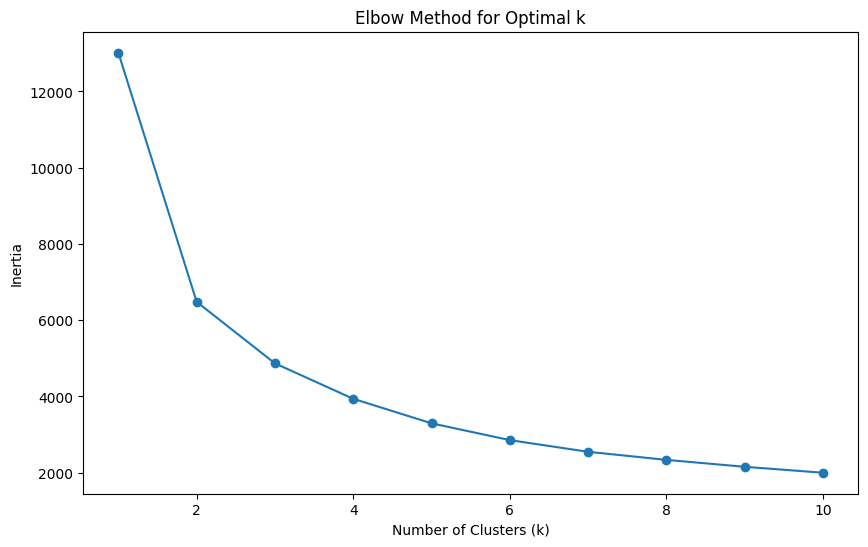

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- Elbow Method ---

# 1. Initialize lists to store inertia and k values
inertia = []
k_range = range(1, 11)

# 2. This loop calculates the inertia for each value of k
# This was the missing part.
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# --- Plot and save the figure ---

# 3. Create a new figure to draw on
plt.figure(figsize=(10, 6))

# 4. This command actually draws the line plot
# This was also missing.
plt.plot(k_range, inertia, marker='o')

# Add titles and labels for clarity
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Save the figure BEFORE showing it
plt.savefig('../reports/figures/elbow_method.png')

# Show the plot
plt.show()

# --- Final Model ---
# (This part of your code is correct)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)
rfm_df['Cluster'] = kmeans.labels_

# Save the final segmented data
rfm_df.to_csv('../data/processed/rfm_segmented_customers.csv')

Analysis and Visualization

         Recency  Frequency  Monetary
Cluster                              
0           17.1       13.3    7905.4
1          167.4        1.4     362.5
2           44.2        3.4    1265.1


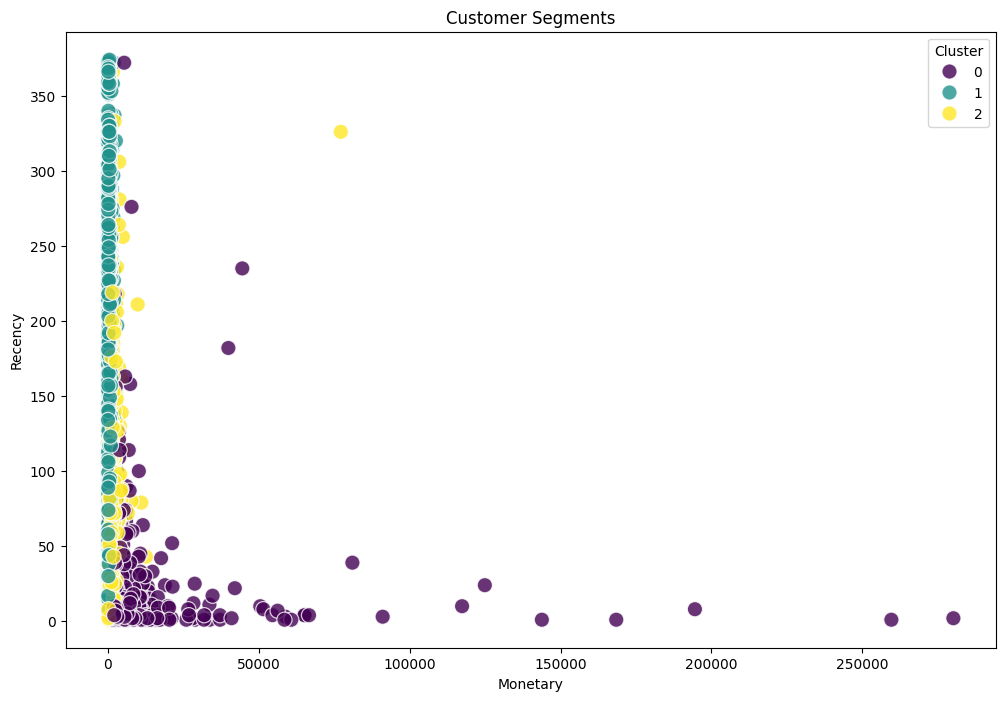

In [5]:
import seaborn as sns

# Analyze the cluster averages
cluster_analysis = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(cluster_analysis)

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=rfm_df, x='Monetary', y='Recency', hue='Cluster', palette='viridis', alpha=0.8, s=120)
plt.title('Customer Segments')

# Save the final plot
plt.savefig('../reports/figures/customer_segments.png')
plt.show()